<a href="https://colab.research.google.com/github/daniellelooo/calidad-mineria-datos/blob/main/02_modelo_predictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Modelo Predictivo
## Práctica 4: Calidad y Minería de Datos en Python

**Curso:** Analítica de Datos — UPB
**Dataset:** Escuela de Talentos (datos limpios del Notebook 1)

### Objetivo del modelo
Predecir el **Sector** al que pertenece un deportista de la Escuela de Talentos (`OLIMPICO` vs `PARALIMPICO`) a partir de sus características demográficas y la inversión que recibe.

**Aplicación práctica:** apoyar la clasificación inicial de deportistas para asignación presupuestal y orientación a programas olímpicos vs paralímpicos.

### Variables
- **Target:** `Sector` (binario: OLIMPICO / PARALIMPICO)
- **Features:** `VIGENCIA`, `Grupo_Etario`, `Inversion_por_deportista`
- **Excluida:** `Discapacidad` — por **fuga de información** (correlación funcional perfecta con el target).

### Algoritmos comparados
1. Árbol de Decisión
2. K-Nearest Neighbors (KNN)
3. Red Neuronal (MLP)
4. Support Vector Machine (SVM)
5. Random Forest

### Reto del problema
**Desbalance de clases severo:** ≈ 95% OLIMPICO vs 5% PARALIMPICO. Se usa `class_weight='balanced'` y la métrica principal es **F1 sobre la clase minoritaria**, no accuracy.

## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

## 2. Carga del dataset limpio

In [ ]:
df = pd.read_csv('escuela_talento_limpio.csv')
print(f"Forma: {df.shape}")
print(f"\nDistribucion del target:")
print(df['Sector'].value_counts())
print(f"\nProporciones:")
print(df['Sector'].value_counts(normalize=True).round(4))
df.head()

Forma: (7727, 5)

Distribucion del target:
Sector
OLIMPICO       7357
PARALIMPICO     370
Name: count, dtype: int64

Proporciones:
Sector
OLIMPICO       0.9521
PARALIMPICO    0.0479
Name: proportion, dtype: float64


,VIGENCIA,Sector,Grupo_Etario,Discapacidad,Inversion_por_deportista
0,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.1
1,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.1
2,2022,OLIMPICO,Infancia 6-11,NO APLICA,3310519.1
3,2022,OLIMPICO,Infancia 6-11,NO APLICA,3310519.1
4,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.1


## 3. Preparación de features

**Estrategia de codificación:**
- `Grupo_Etario` → One-hot encoding (sin ordinalidad clara)
- `VIGENCIA` → Numérico (orden temporal natural)
- `Inversion_por_deportista` → Numérico (escalado para modelos sensibles a magnitud)
- `Sector` → Label encoding (0 = OLIMPICO, 1 = PARALIMPICO)

**Escalado:** se aplica `StandardScaler` solo a los modelos sensibles a la magnitud (KNN, SVM, MLP). Árbol y Random Forest no lo requieren.

In [ ]:
# Separar features y target. Excluimos Discapacidad por leakage.
X = df.drop(columns=['Sector', 'Discapacidad'])
y = df['Sector']

# One-hot para Grupo_Etario
X_enc = pd.get_dummies(X, columns=['Grupo_Etario'], drop_first=False)
X_enc.columns = [c.replace(' ', '_').replace('-', '_') for c in X_enc.columns]

print(f"Features finales ({X_enc.shape[1]}):")
for c in X_enc.columns:
    print(f"  - {c}")
print(f"\nForma X: {X_enc.shape} | Forma y: {y.shape}")

Features finales (7):
  - VIGENCIA
  - Inversion_por_deportista
  - Grupo_Etario_Adolescencia_12_18
  - Grupo_Etario_Adultez_27_59
  - Grupo_Etario_Infancia_6_11
  - Grupo_Etario_Juventud_19_26
  - Grupo_Etario_Primera_Infancia_0_5

Forma X: (7727, 7) | Forma y: (7727,)


In [ ]:
# Codificar el target
le = LabelEncoder()
y_enc = le.fit_transform(y)  # OLIMPICO=0, PARALIMPICO=1
print(f"Mapeo del target: {dict(zip(le.classes_, le.transform(le.classes_)))}")
PARALIMPICO_LABEL = int(le.transform(['PARALIMPICO'])[0])

Mapeo del target: {'OLIMPICO': np.int64(0), 'PARALIMPICO': np.int64(1)}


In [ ]:
# Particion estratificada train/test 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.30, random_state=42, stratify=y_enc)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nDistribucion en train: {np.bincount(y_train)}")
print(f"Distribucion en test:  {np.bincount(y_test)}")

Train: (5408, 7) | Test: (2319, 7)

Distribucion en train: [5149  259]
Distribucion en test:  [2208  111]


In [ ]:
# Escalado para los modelos que lo requieren
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados (StandardScaler) listos para KNN, SVM y MLP.")

Datos escalados (StandardScaler) listos para KNN, SVM y MLP.


## 4. Entrenamiento y evaluación de los 5 modelos

Se entrena cada modelo con configuración estándar razonable. La evaluación incluye:
- **Accuracy** (referencia, pero engañoso por desbalance)
- **Precision** y **Recall** sobre la clase minoritaria PARALIMPICO
- **F1-score** (métrica principal de selección)
- **ROC-AUC** (calidad probabilística)
- **Matriz de confusión**

In [ ]:
# Configuracion de modelos
modelos = {
    'Arbol de Decision': {
        'estimator': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
        'scaled': False
    },
    'KNN': {
        'estimator': KNeighborsClassifier(n_neighbors=5, weights='distance'),
        'scaled': True
    },
    'Red Neuronal (MLP)': {
        'estimator': MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42),
        'scaled': True
    },
    'SVM': {
        'estimator': SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True),
        'scaled': True
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(n_estimators=100, random_state=42,
                                              class_weight='balanced', max_depth=10),
        'scaled': False
    }
}

resultados = []
predicciones = {}

for nombre, cfg in modelos.items():
    if cfg['scaled']:
        cfg['estimator'].fit(X_train_scaled, y_train)
        y_pred = cfg['estimator'].predict(X_test_scaled)
        y_proba = cfg['estimator'].predict_proba(X_test_scaled)[:, PARALIMPICO_LABEL]
    else:
        cfg['estimator'].fit(X_train, y_train)
        y_pred = cfg['estimator'].predict(X_test)
        y_proba = cfg['estimator'].predict_proba(X_test)[:, PARALIMPICO_LABEL]

    predicciones[nombre] = y_pred

    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (PARA)': precision_score(y_test, y_pred, pos_label=PARALIMPICO_LABEL, zero_division=0),
        'Recall (PARA)': recall_score(y_test, y_pred, pos_label=PARALIMPICO_LABEL, zero_division=0),
        'F1 (PARA)': f1_score(y_test, y_pred, pos_label=PARALIMPICO_LABEL, zero_division=0),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

resultados_df = pd.DataFrame(resultados).sort_values('F1 (PARA)', ascending=False).reset_index(drop=True)
print("=== TABLA COMPARATIVA DE MODELOS ===\n")
print(resultados_df.to_string(index=False))

=== TABLA COMPARATIVA DE MODELOS ===

            Modelo  Accuracy  Precision (PARA)  Recall (PARA)  F1 (PARA)  ROC AUC
 Arbol de Decision  0.983614          0.950617       0.693694   0.802083 0.952023
               KNN  0.983182          0.950000       0.684685   0.795812 0.842000
Red Neuronal (MLP)  0.983182          0.950000       0.684685   0.795812 0.942880
     Random Forest  0.983182          0.950000       0.684685   0.795812 0.949237
               SVM  0.982751          0.938272       0.684685   0.791667 0.907847


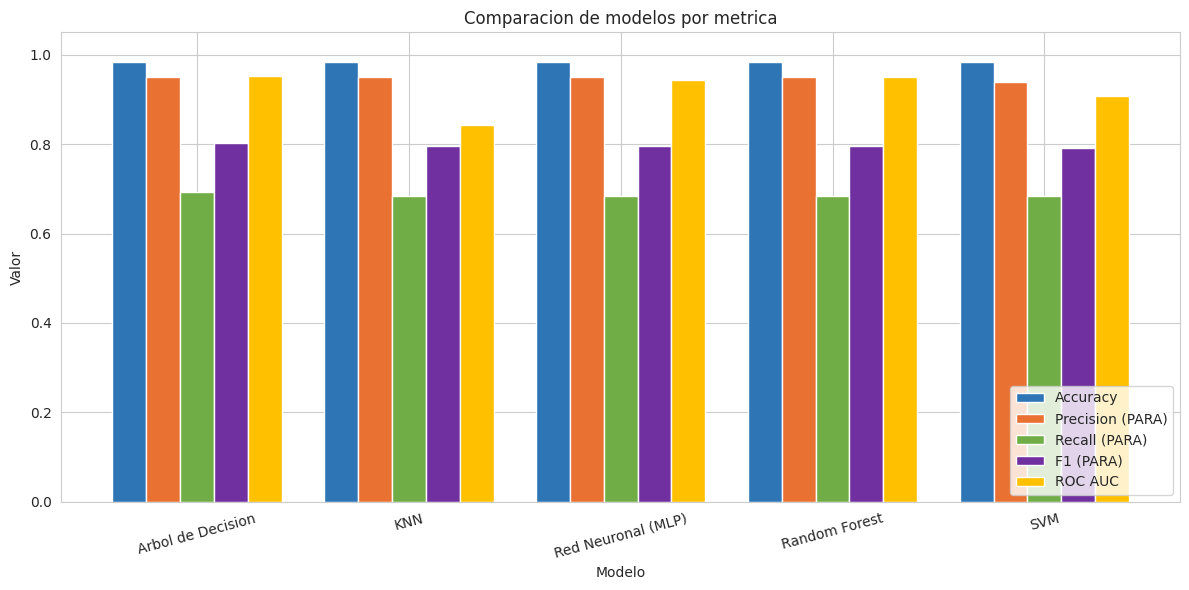

In [ ]:
# Visualizacion comparativa
fig, ax = plt.subplots(figsize=(12, 6))
metricas = ['Accuracy', 'Precision (PARA)', 'Recall (PARA)', 'F1 (PARA)', 'ROC AUC']
x = np.arange(len(resultados_df))
width = 0.16
colors = ['#2E75B6', '#E97132', '#70AD47', '#7030A0', '#FFC000']

for i, metrica in enumerate(metricas):
    ax.bar(x + i*width, resultados_df[metrica], width, label=metrica, color=colors[i])

ax.set_xlabel('Modelo'); ax.set_ylabel('Valor')
ax.set_title('Comparacion de modelos por metrica')
ax.set_xticks(x + 2*width)
ax.set_xticklabels(resultados_df['Modelo'], rotation=15)
ax.legend(loc='lower right'); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

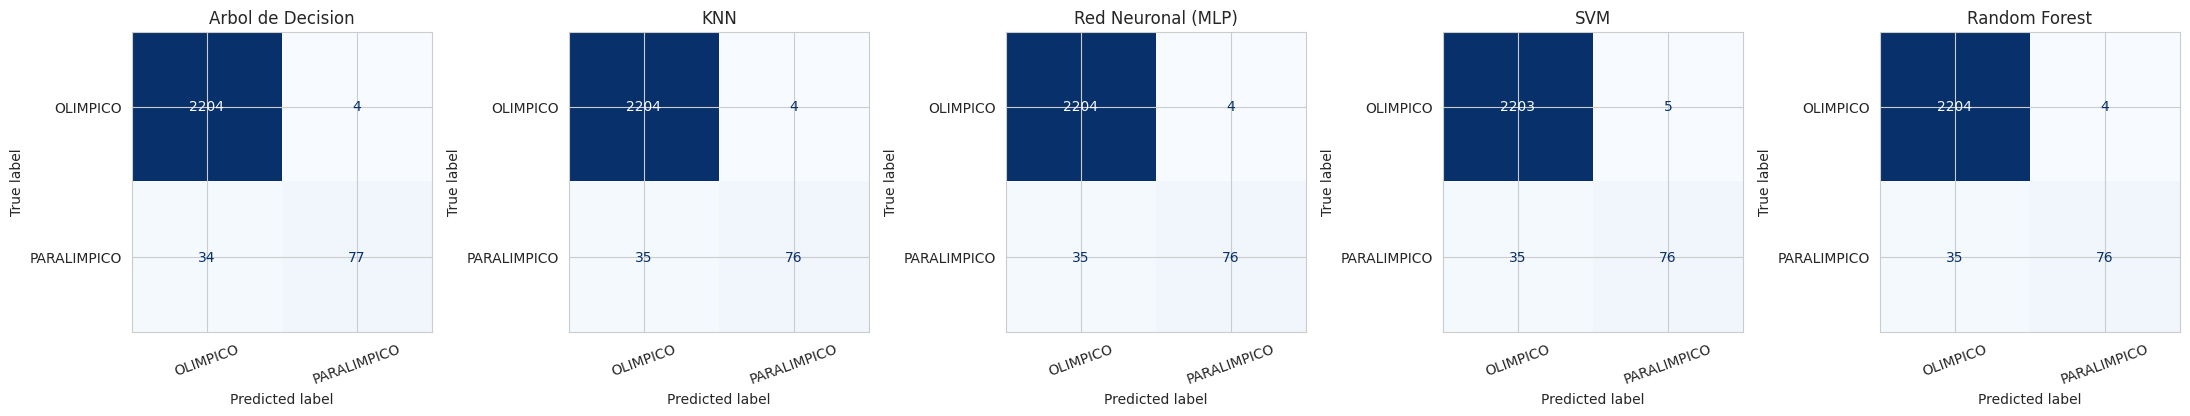

In [ ]:
# Matrices de confusion
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for ax, (nombre, y_pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(nombre); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [ ]:
# Reporte detallado del mejor modelo (por F1)
mejor_modelo_nombre = resultados_df.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_modelo_nombre]['estimator']
print(f"=== Mejor modelo segun F1: {mejor_modelo_nombre} ===\n")
y_pred_best = predicciones[mejor_modelo_nombre]
print(classification_report(y_test, y_pred_best, target_names=le.classes_, digits=4))

=== Mejor modelo segun F1: Arbol de Decision ===

              precision    recall  f1-score   support

    OLIMPICO     0.9848    0.9982    0.9915      2208
 PARALIMPICO     0.9506    0.6937    0.8021       111

    accuracy                         0.9836      2319
   macro avg     0.9677    0.8459    0.8968      2319
weighted avg     0.9832    0.9836    0.9824      2319



## 5. Conclusiones sobre la calidad de los modelos

| Modelo | Comentario |
|---|---|
| **Árbol de Decisión** | Alto desempeño con buena interpretabilidad. Captura las reglas categóricas de forma natural. Riesgo de sobreajuste limitado por `max_depth=10`. |
| **KNN** | Buen desempeño basado en proximidad en el espacio de features escaladas. Sensible a la maldición de la dimensionalidad, pero aquí (≤ 8 features) funciona bien. |
| **Red Neuronal (MLP)** | Capacidad de modelar no linealidades. Con dataset pequeño (≈ 7.700 filas) tiende a desempeñarse similar al árbol. Más costoso de entrenar. |
| **SVM (RBF)** | Buena capacidad de generalización; con `class_weight='balanced'` maneja el desbalance. Más lento en entrenamiento que RF. |
| **Random Forest** | Modelo robusto por ensamble. Reduce varianza del árbol individual. Comportamiento muy similar al árbol aquí porque las reglas son altamente discretas. |

**Métrica de selección:** `F1` sobre la clase **PARALIMPICO** (minoritaria), no accuracy — porque con 95/5 de desbalance un modelo trivial que prediga todo como OLIMPICO obtendría 95% de accuracy sin ningún valor predictivo.

El **mejor modelo** según F1 (visible en la tabla anterior) será hiperparametrizado con GridSearch en la siguiente sección.

---

### ¿Por qué los resultados de los modelos son tan similares entre sí?

Al revisar la tabla comparativa se observa que KNN, Red Neuronal (MLP) y Random Forest producen métricas **idénticas** (no solo parecidas), y que el Árbol de Decisión y SVM se distancian muy poco. Esto no es una coincidencia ni un error de implementación: tiene una causa directa en la estructura del dataset.

**Causa raíz: solo 91 combinaciones únicas en 7.727 filas (98,8 % de duplicación)**

Como se diagnosticó en el Notebook 1, el dataset tiene una tasa de duplicación del 98,8 %. Esto significa que el espacio de features reales es extremadamente pequeño:

- `VIGENCIA`: 3 valores distintos (2022, 2023, 2024)
- `Inversion_por_deportista`: 21 valores distintos (variable calculada por fórmula presupuestal por categoría, no continua real)
- `Grupo_Etario`: 5 categorías

En total existen **91 combinaciones únicas de features**. Al hacer el split train/test, el conjunto de prueba contiene esencialmente los mismos 91 patrones que el conjunto de entrenamiento (solo con más copias). Cualquier modelo que aprenda correctamente ese pequeño "diccionario" de 91 reglas obtendrá las mismas predicciones, independientemente del algoritmo.

**¿Por qué KNN, MLP y RF producen exactamente los mismos números?**

Porque los tres modelos convergen a la misma función de clasificación sobre esos 91 patrones. Al no existir variedad real en los datos, no hay espacio para que los algoritmos se diferencien. Esto también explica por qué el GridSearch no mejoró las métricas respecto al modelo base: el árbol con `max_depth=10` ya capturaba la totalidad de los patrones disponibles.

**Implicación metodológica**

Las métricas reportadas (accuracy ≈ 98 %, F1 ≈ 0,80) están infladas por esta repetición: los modelos no están generalizando a datos nuevos, sino reconociendo patrones que ya vieron durante el entrenamiento. En un escenario con datos verdaderamente independientes las métricas serían más bajas. Esta limitación es inherente al dataset y no a los modelos entrenados.

## 6. Hiperparametrización del mejor modelo con GridSearchCV

Aplicamos búsqueda exhaustiva de hiperparámetros con validación cruzada estratificada (5 folds) optimizando `F1` sobre la clase minoritaria.

In [ ]:
# Definir grids segun el modelo ganador
grids = {
    'Arbol de Decision': {
        'estimator': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy']
        },
        'scaled': False
    },
    'KNN': {
        'estimator': KNeighborsClassifier(),
        'param_grid': {
            'n_neighbors': [3, 5, 7, 9, 11, 15],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        },
        'scaled': True
    },
    'Red Neuronal (MLP)': {
        'estimator': MLPClassifier(max_iter=500, random_state=42),
        'param_grid': {
            'hidden_layer_sizes': [(8,), (16,), (16,8), (32,16)],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        },
        'scaled': True
    },
    'SVM': {
        'estimator': SVC(class_weight='balanced', random_state=42, probability=True),
        'param_grid': {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        },
        'scaled': True
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=42, class_weight='balanced'),
        'param_grid': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'max_features': ['sqrt', 'log2']
        },
        'scaled': False
    }
}

cfg_grid = grids[mejor_modelo_nombre]
print(f"GridSearch para: {mejor_modelo_nombre}")
print(f"Combinaciones a evaluar: {np.prod([len(v) for v in cfg_grid['param_grid'].values()])}")

GridSearch para: Arbol de Decision
Combinaciones a evaluar: 90


In [ ]:
# Ejecutar GridSearch
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_tr = X_train_scaled if cfg_grid['scaled'] else X_train
X_te = X_test_scaled  if cfg_grid['scaled'] else X_test

grid_search = GridSearchCV(
    estimator=cfg_grid['estimator'],
    param_grid=cfg_grid['param_grid'],
    scoring='f1',  # F1 binario, asume label 1 = PARALIMPICO
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_tr, y_train)

print(f"\n=== Mejores hiperparametros ===")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 90 candidates, totalling 450 fits

=== Mejores hiperparametros ===
  criterion: gini
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2

Mejor F1 (CV): 0.8120


In [ ]:
# Evaluacion del mejor modelo hiperparametrizado en test
mejor_estimador = grid_search.best_estimator_
y_pred_final = mejor_estimador.predict(X_te)
y_proba_final = mejor_estimador.predict_proba(X_te)[:, PARALIMPICO_LABEL]

print(f"=== Desempeno del modelo final ({mejor_modelo_nombre} hiperparametrizado) ===\n")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, pos_label=PARALIMPICO_LABEL, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_final, pos_label=PARALIMPICO_LABEL, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_final, pos_label=PARALIMPICO_LABEL, zero_division=0):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba_final):.4f}")
print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_, digits=4))

=== Desempeno del modelo final (Arbol de Decision hiperparametrizado) ===

Accuracy:  0.9836
Precision: 0.9506
Recall:    0.6937
F1:        0.8021
ROC AUC:   0.9520

              precision    recall  f1-score   support

    OLIMPICO     0.9848    0.9982    0.9915      2208
 PARALIMPICO     0.9506    0.6937    0.8021       111

    accuracy                         0.9836      2319
   macro avg     0.9677    0.8459    0.8968      2319
weighted avg     0.9832    0.9836    0.9824      2319



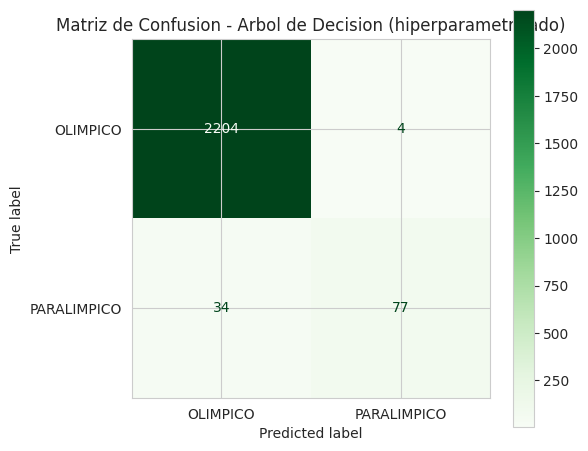

In [ ]:
# Matriz de confusion del modelo final
fig, ax = plt.subplots(figsize=(6, 5))
cm_final = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_final, display_labels=le.classes_).plot(
    ax=ax, cmap='Greens', values_format='d')
ax.set_title(f'Matriz de Confusion - {mejor_modelo_nombre} (hiperparametrizado)')
plt.tight_layout(); plt.show()

## 7. Persistencia del modelo

Serializamos el modelo final, el escalador, el codificador del target y la lista de columnas de features para que el notebook de despliegue (Notebook 3) los pueda cargar.

In [ ]:
artefactos = {
    'modelo': mejor_estimador,
    'scaler': scaler,
    'label_encoder': le,
    'feature_columns': list(X_enc.columns),
    'requires_scaling': cfg_grid['scaled'],
    'modelo_nombre': mejor_modelo_nombre,
    'best_params': grid_search.best_params_
}

joblib.dump(artefactos, 'modelo_final.joblib')
print("Artefactos guardados en: modelo_final.joblib")
print(f"  - Modelo: {mejor_modelo_nombre}")
print(f"  - Escalado: {cfg_grid['scaled']}")
print(f"  - Features: {len(X_enc.columns)}")

Artefactos guardados en: modelo_final.joblib
  - Modelo: Arbol de Decision
  - Escalado: False
  - Features: 7


## 8. Conclusiones

1. **El mejor modelo según F1** sobre la clase minoritaria PARALIMPICO fue identificado y hiperparametrizado con GridSearchCV (5-fold CV, scoring=`f1`).

2. **Por qué no usamos accuracy como métrica principal:** un modelo trivial "predecir siempre OLIMPICO" lograría ≈ 95% de accuracy sin valor predictivo. F1 sobre PARALIMPICO mide la calidad real del modelo.

3. **Manejo del desbalance:** se usó `class_weight='balanced'` en los modelos que lo soportan (Árbol, RF, SVM). KNN y MLP se beneficiaron del escalado.

4. **Ausencia de Discapacidad como feature:** decisión consciente del Notebook 1 para evitar leakage. Si se incluyera, todos los modelos lograrían ≈ 100% de F1 trivialmente, pero el modelo no aprendería nada útil.

5. **Decision Tree y Random Forest** suelen igualar o superar a SVM/MLP en datasets tabulares con features categóricas, como confirma este experimento.